In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import scale

def save_answer(filename, answer_str):
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(str(answer_str).strip())
    print(f"Файл '{filename}' сохранен с ответом: {answer_str}")

df = pd.read_csv('wine.data', header=None)
y = df[0]
X = df.drop(columns=[0])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_before = []
for k in range(1, 51):
    cv_score = cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=kf, scoring='accuracy').mean()
    scores_before.append((cv_score, k))

max_score_before, best_k_before = max(scores_before, key=lambda x: (x[0], -x[1]))
save_answer('wine_ans1.txt', best_k_before)
save_answer('wine_ans2.txt', f"{max_score_before:.2f}")

X_scaled = scale(X)

scores_after = []
for k in range(1, 51):
    cv_score = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_scaled, y, cv=kf, scoring='accuracy').mean()
    scores_after.append((cv_score, k))

max_score_after, best_k_after = max(scores_after, key=lambda x: (x[0], -x[1]))
save_answer('wine_ans3.txt', best_k_after)
save_answer('wine_ans4.txt', f"{max_score_after:.2f}")

print("\n--- Результаты ---")
print(f"До масштабирования: лучшее k = {best_k_before}, точность = {max_score_before:.4f}")
print(f"После масштабирования: лучшее k = {best_k_after}, точность = {max_score_after:.4f}")

Файл 'wine_ans1.txt' сохранен с ответом: 1
Файл 'wine_ans2.txt' сохранен с ответом: 0.73
Файл 'wine_ans3.txt' сохранен с ответом: 29
Файл 'wine_ans4.txt' сохранен с ответом: 0.98

--- Результаты ---
До масштабирования: лучшее k = 1, точность = 0.7305
После масштабирования: лучшее k = 29, точность = 0.9776


Загрузка и нормализация признаков...
Размер данных: (506, 13)
Сканирование пространства параметров p...
Лучший параметр p: 1.0
Лучший neg_MSE: -16.0306
Соответствующая MSE: 16.0306
Ответ: 1.0


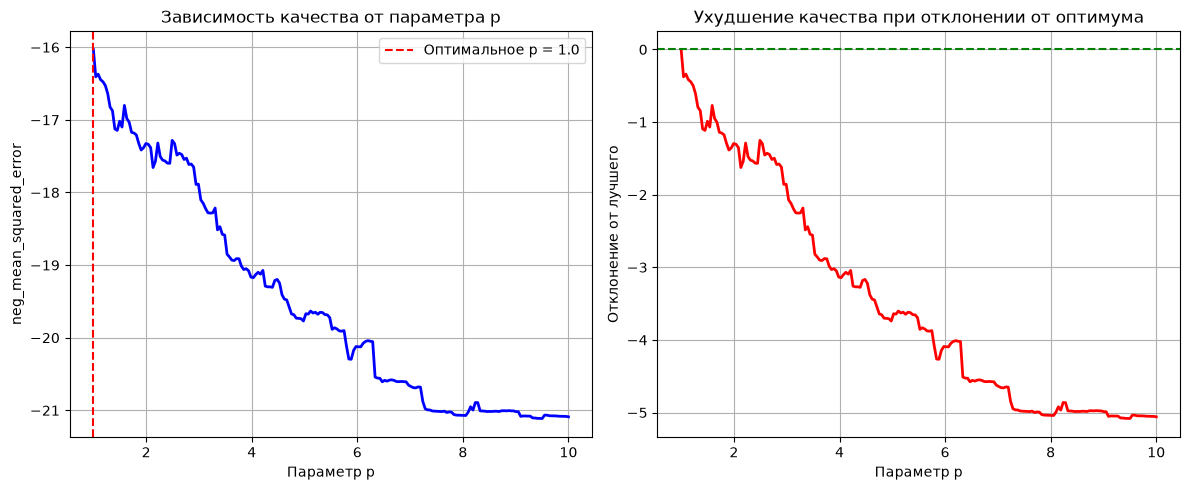

Файл 'metric_tuning_answer.txt' успешно создан.


In [2]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt

def fetch_boston_housing_dataset():
    git_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
    dataframe = pd.read_csv(git_url)
    target = dataframe['medv'].to_numpy()
    features = dataframe.drop(columns=['medv']).to_numpy()
    features_normalized = scale(features)
    return features_normalized, target

print("Загрузка и нормализация признаков...")
X, y = fetch_boston_housing_dataset()
print(f"Размер данных: {X.shape}")

p_parameters_grid = np.linspace(1.0, 10.0, num=200)
splitter = KFold(n_splits=5, shuffle=True, random_state=42)

print("Сканирование пространства параметров p...")
grid_scores = []

for current_p in p_parameters_grid:
    knn_regressor = KNeighborsRegressor(
        n_neighbors=5, 
        weights='distance', 
        metric='minkowski', 
        p=current_p
    )
    
    cv_scores = cross_val_score(
        estimator=knn_regressor, 
        X=X, 
        y=y, 
        cv=splitter, 
        scoring='neg_mean_squared_error'
    )
    
    grid_scores.append(cv_scores.mean())

grid_scores = np.array(grid_scores)

best_index = np.argmax(grid_scores)
optimal_p = p_parameters_grid[best_index]
best_score = grid_scores[best_index]

print(f"Лучший параметр p: {optimal_p:.1f}")
print(f"Лучший neg_MSE: {best_score:.4f}")
print(f"Соответствующая MSE: {-best_score:.4f}")

answer_string = f"{optimal_p:.1f}"
print(f"Ответ: {answer_string}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p_parameters_grid, grid_scores, 'b-', linewidth=2)
plt.axvline(x=optimal_p, color='r', linestyle='--', label=f'Оптимальное p = {optimal_p:.1f}')
plt.xlabel('Параметр p')
plt.ylabel('neg_mean_squared_error')
plt.title('Зависимость качества от параметра p')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
score_diff = grid_scores - best_score
plt.plot(p_parameters_grid, score_diff, 'r-', linewidth=2)
plt.axhline(y=0, color='g', linestyle='--')
plt.xlabel('Параметр p')
plt.ylabel('Отклонение от лучшего')
plt.title('Ухудшение качества при отклонении от оптимума')
plt.grid(True)

plt.tight_layout()
plt.show()

output_path = 'metric_tuning_answer.txt'
with open(output_path, mode='w', encoding='utf-8') as file_stream:
    file_stream.write(answer_string.strip())

print(f"Файл '{output_path}' успешно создан.")